Group Members: Andrew Mankin, Ryan Safa

So there is no reduced feature set

We are also just going to do a simple cnn

In [123]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import tensorflow as tf
from tensorflow.keras import layers, models
import matplotlib.image as img
import os
import cv2
from sklearn.model_selection import train_test_split
tf.keras.backend.clear_session()

In [124]:
df = pd.read_csv("./dataset/labels.csv")

In [125]:
df

,image,photometric,label
0,./dataset/images/sub-S03224_ses-E08049_run-1_b...,MONOCHROME1,1
1,./dataset/images/sub-S28417_ses-E60904_run-2_b...,MONOCHROME2,0
2,./dataset/images/sub-S03071_ses-E06165_run-1_b...,MONOCHROME2,1
3,./dataset/images/sub-S03113_ses-E07104_run-1_b...,MONOCHROME1,1
4,./dataset/images/sub-S03119_ses-E06213_run-1_b...,MONOCHROME2,1
...,...,...,...
1252,./dataset/images/sub-S08032_ses-E14275_run-1_b...,MONOCHROME2,0
1253,./dataset/images/sub-S03106_ses-E06431_acq-2_r...,MONOCHROME2,1
1254,./dataset/images/sub-S03056_ses-E07055_run-1_b...,MONOCHROME2,1
1255,./dataset/images/sub-S05731_ses-E10513_run-1_b...,MONOCHROME2,0


preprocess all the image paths to matplotlib images

In [126]:
def load_image(path):
    img = cv2.imread(path, cv2.IMREAD_GRAYSCALE)

    if img is None:
        print("Bad image:", path)
        return None

    img = cv2.resize(img, (224, 224))
    img = img.astype("float32") / 255.0
    #img = np.stack([img, img, img], axis=-1)
    return img

In [127]:
images = []
labels = []

for path, label in zip(df["image"], df["label"]):
    img = load_image(path)
    if img is None:
        continue
    images.append(img)
    labels.append(label)

X = np.array(images, dtype=np.float32)
y = np.array(labels, dtype=np.float32)

libpng warning: bKGD: invalid
libpng warning: bKGD: invalid
libpng warning: bKGD: invalid
libpng warning: bKGD: invalid
libpng warning: bKGD: invalid
libpng warning: bKGD: invalid
libpng warning: bKGD: invalid


In [128]:
X = np.expand_dims(X, axis=-1)

In [129]:
print("X shape:", X.shape)
print("X dtype:", X.dtype)
print("X min/max:", X.min(), X.max())

print("y shape:", y.shape)
print("y dtype:", y.dtype)
print("labels:", set(y))

X shape: (1257, 224, 224, 1)
X dtype: float32
X min/max: 0.0 1.0
y shape: (1257,)
y dtype: float32
labels: {np.float32(0.0), np.float32(1.0)}


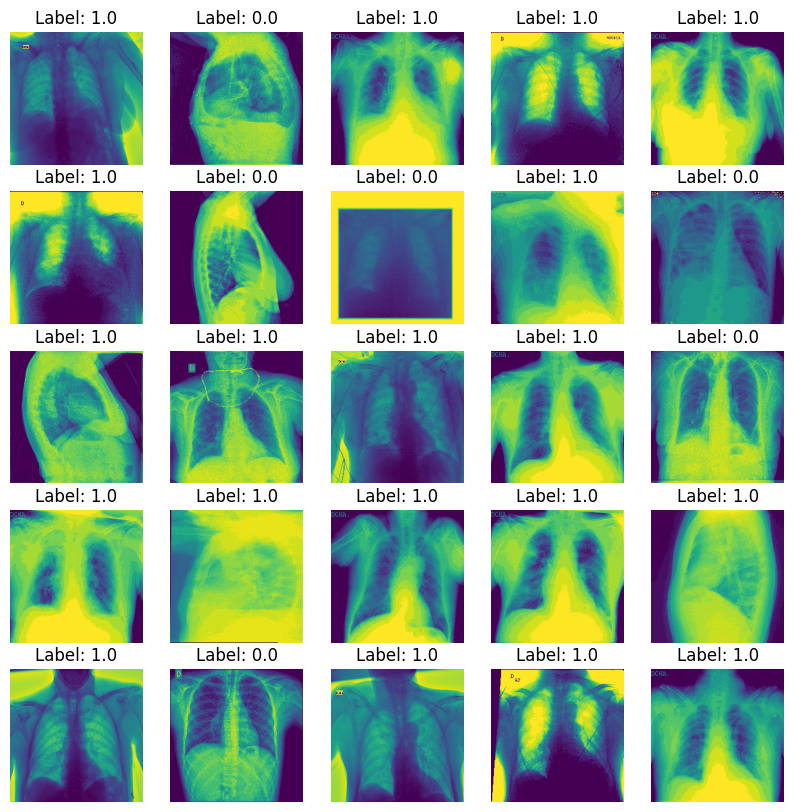

In [130]:
# verifiy the data
plt.figure(figsize=(10,10))
for i in range(25):
    plt.subplot(5, 5, i+1)
    plt.imshow(X[i])
    plt.title(f"Label: {y[i]}")
    plt.axis('off')
plt.show()

Split the data into train and test

In [131]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    stratify=y,
    random_state=42
)

In [132]:
print(X_train.shape)
print(X_test.shape)


(1005, 224, 224, 1)
(252, 224, 224, 1)


In [133]:
base_model = tf.keras.applications.EfficientNetB0(
    include_top=False,
    weights="imagenet",
    input_shape=(224, 224, 3)
)
"""
model = tf.keras.models.Sequential([
    tf.keras.Input(shape=(224, 224, 1)),
    tf.keras.layers.Conv2D(32, (3,3), activation='relu'),
    tf.keras.layers.MaxPooling2D((2,2)),
    tf.keras.layers.Conv2D(64, (3,3), activation='relu'),
    tf.keras.layers.MaxPooling2D((2,2)),
    tf.keras.layers.Conv2D(128, (3,3), activation='relu'),
    tf.keras.layers.MaxPooling2D((2,2)),

    tf.keras.layers.Flatten(),
    tf.keras.layers.Dense(64, activation='relu'),
    tf.keras.layers.Dropout(0.4),
    tf.keras.layers.Dense(1, activation='sigmoid')  # binary classification
])
"""

"\nmodel = tf.keras.models.Sequential([\n    tf.keras.Input(shape=(224, 224, 1)),\n    tf.keras.layers.Conv2D(32, (3,3), activation='relu'),\n    tf.keras.layers.MaxPooling2D((2,2)),\n    tf.keras.layers.Conv2D(64, (3,3), activation='relu'),\n    tf.keras.layers.MaxPooling2D((2,2)),\n    tf.keras.layers.Conv2D(128, (3,3), activation='relu'),\n    tf.keras.layers.MaxPooling2D((2,2)),\n\n    tf.keras.layers.Flatten(),\n    tf.keras.layers.Dense(64, activation='relu'),\n    tf.keras.layers.Dropout(0.4),\n    tf.keras.layers.Dense(1, activation='sigmoid')  # binary classification\n])\n"

In [134]:
base_model.summary()

Model: "efficientnetb0"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ rescaling           │ (None, 224, 224,  │          0 │ input_layer[0][0] │
│ (Rescaling)         │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ normalization       │ (None, 224, 224,  │          7 │ rescaling[0][0]   │
│ (Normalization)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ rescaling_1         │ (None, 224, 224,  │          0 │ normalization[0]… │
│ (Rescaling)         │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_conv_pad       │ (None, 225, 225,  │          0 │ rescaling_1[0][0] │
│ (ZeroPadding2D)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_conv (Conv2D)  │ (None, 112, 112,  │        864 │ stem_conv_pad[0]… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_bn             │ (None, 112, 112,  │        128 │ stem_conv[0][0]   │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_activation     │ (None, 112, 112,  │          0 │ stem_bn[0][0]     │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_dwconv      │ (None, 112, 112,  │        288 │ stem_activation[… │
│ (DepthwiseConv2D)   │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_bn          │ (None, 112, 112,  │        128 │ block1a_dwconv[0… │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_activation  │ (None, 112, 112,  │          0 │ block1a_bn[0][0]  │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_squeeze  │ (None, 32)        │          0 │ block1a_activati… │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_reshape  │ (None, 1, 1, 32)  │          0 │ block1a_se_squee… │
│ (Reshape)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_reduce   │ (None, 1, 1, 8)   │        264 │ block1a_se_resha… │
│ (Conv2D)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_expand   │ (None, 1, 1, 32)  │        288 │ block1a_se_reduc… │
│ (Conv2D)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_excite   │ (None, 112, 112,  │          0 │ block1a_activati… │
│ (Multiply)          │ 32)               │            │ block1a_se_expan… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_project_co… │ (None, 112, 112,  │        512 │ block1a_se_excit

 Total params: 4,049,571 (15.45 MB)

 Trainable params: 4,007,548 (15.29 MB)

 Non-trainable params: 42,023 (164.16 KB)

In [135]:
inputs = tf.keras.Input(shape=(224, 224, 1))
x = layers.Lambda(lambda x: tf.image.grayscale_to_rgb(x))(inputs)
# EfficientNet backbone
x = base_model(x, training=False)

# classification head
x = layers.GlobalAveragePooling2D()(x)
x = layers.Dropout(0.3)(x)
outputs = layers.Dense(1, activation="sigmoid")(x)

model = tf.keras.Model(inputs, outputs)

In [136]:
model.compile(
    optimizer=tf.keras.optimizers.Adam(1e-4),
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

In [137]:
history = model.fit(
    X_train, y_train,
    validation_data=(X_test, y_test),
    epochs=10,
    batch_size=32
)

Epoch 1/10
32/32 ━━━━━━━━━━━━━━━━━━━━ 126s 3s/step - accuracy: 0.6975 - loss: 0.5729 - val_accuracy: 0.3056 - val_loss: 0.7147
Epoch 2/10
32/32 ━━━━━━━━━━━━━━━━━━━━ 97s 3s/step - accuracy: 0.8129 - loss: 0.4143 - val_accuracy: 0.3056 - val_loss: 0.7025
Epoch 3/10
32/32 ━━━━━━━━━━━━━━━━━━━━ 98s 3s/step - accuracy: 0.8428 - loss: 0.3579 - val_accuracy: 0.6944 - val_loss: 0.6843
Epoch 4/10
32/32 ━━━━━━━━━━━━━━━━━━━━ 98s 3s/step - accuracy: 0.8736 - loss: 0.3038 - val_accuracy: 0.6984 - val_loss: 0.6740
Epoch 5/10
32/32 ━━━━━━━━━━━━━━━━━━━━ 98s 3s/step - accuracy: 0.9015 - loss: 0.2535 - val_accuracy: 0.6944 - val_loss: 0.6408
Epoch 6/10
32/32 ━━━━━━━━━━━━━━━━━━━━ 98s 3s/step - accuracy: 0.9184 - loss: 0.2190 - val_accuracy: 0.6944 - val_loss: 0.6471
Epoch 7/10
32/32 ━━━━━━━━━━━━━━━━━━━━ 98s 3s/step - accuracy: 0.9423 - loss: 0.1645 - val_accuracy: 0.6984 - val_loss: 0.6307
Epoch 8/10
32/32 ━━━━━━━━━━━━━━━━━━━━ 98s 3s/step - accuracy: 0.9592 - loss: 0.1285 - val_accuracy: 0.6944 - val_loss

8/8 - 5s - 649ms/step - accuracy: 0.3889 - loss: 0.9251


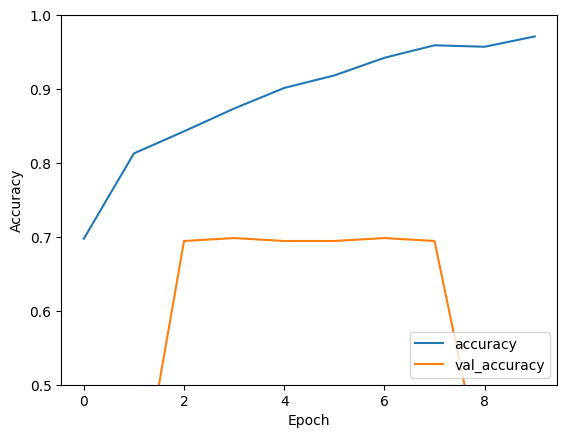

In [140]:
plt.plot(history.history['accuracy'], label='accuracy')
plt.plot(history.history['val_accuracy'], label = 'val_accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.ylim([0.5, 1])
plt.legend(loc='lower right')

test_loss, test_acc = model.evaluate(X_test,  y_test, verbose=2)

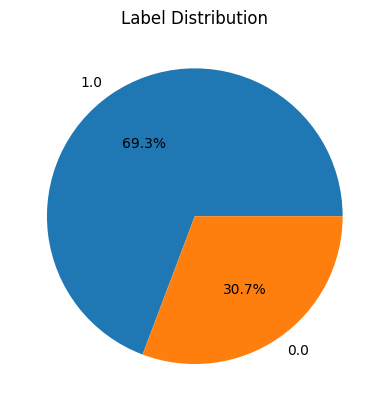

In [141]:

counts = pd.Series(y_train).value_counts()

plt.pie(counts, labels=counts.index, autopct='%1.1f%%')
plt.title("Label Distribution")
plt.show()